# Visium HD ONT (isoform)

This notebook demonstrates essential steps for analyzing spatial isoform usage using **Visium HD with long-read (ONT) sequencing data**:

1. Load preprocessed transcript-level quantification.
2. Run FFT-accelerated spatial variability tests with `SplisosmFFT`.
3. Compare results across spatial resolutions and with `SplisosmNP`.

For differential usage testing with `SplisosmFFT`, see the [Visium HD FFPE (probe) Part II tutorial](./visiumhd_ffpe_du.ipynb).

Estimated runtime: ~5 min.

## Preliminary notes

In this tutorial, we use a Visium HD 3' adult mouse brain (fresh frozen) data sequenced with Oxford Nanopore. For dataset access and workflow details, please check [the official release page from EPI2ME](https://epi2me.nanoporetech.com/visium_hd_2025.06/). 

Specifically, we downloaded the following outputs from the EPI2ME page:

```bash
- spaceranger/hac/HD_Adult_Mouse_Brain/
  # Space Ranger outputs (`possorted_genome_bam.bam` is not required).
- wf-single-cell/sup/SAMPLE_S1_L001/SAMPLE_S1_L001.transcript_raw_feature_bc_matrix_2um/
  # transcript-level count matrix (generated by EPI2ME with a custom pipeline).
- wf-single-cell/sup/SAMPLE_S1_L001/SAMPLE_S1_L001.transcriptome.gff.gz
  # GFF transcript annotation file.
```

We then ran `convert_mtx_to_h5.py` (available under the [scripts directory](https://github.com/JiayuSuPKU/SPLISOSM/tree/main/scripts)) to prepare a barcode-by-transcript count matrix `raw_tx_bc_matrix.h5`, keeping only reference isoforms.

```bash
python convert_mtx_to_h5.py \
  './wf-single-cell/sup/SAMPLE_S1_L001/SAMPLE_S1_L001.transcript_raw_feature_bc_matrix_2um' \
  './wf-single-cell/sup/SAMPLE_S1_L001/SAMPLE_S1_L001.transcriptome.gff.gz' \
  'raw_tx_bc_matrix.h5'
```


## Imports

In [1]:
from __future__ import annotations

import gzip
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import spatialdata as sd
import spatialdata_plot
from spatialdata import rasterize_bins

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.utils import counts_to_ratios

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)

## Configure paths and core parameters

In [3]:
# Input data (provided by user)
sdata_zarr = Path("/path/to/sdata_tx.filtered.zarr")
gff_file = Path("/path/to/SAMPLE_S1_L001.transcriptome.gff.gz")

# Resolution for primary testing
dataset_id = ""
test_table = "square_016um"
test_bins_element = f"{dataset_id}_{test_table}"

# Feature grouping and quality filters
group_iso_candidates = ["gene_ids", "gene_id"]
gene_name_candidates = ["gene_name", "gene_symbol", "gene_names"]

In [4]:
# local path
sdata_zarr = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ont_mouse_cbs/sdata_tx.filtered.zarr")
gff_file = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ont_mouse_cbs/SAMPLE_S1_L001.transcriptome.gff.gz")

ONT data is generally more sparse than short-read data. To test as many genes as possible, we use a more lenient `min_bin_pct` threshold (the minimum percentage of non-zero bins required to keep an isoform).

In [5]:
# Isoform and gene filtering thresholds
min_counts = 10
min_bin_pct = 0.001 # a more lenient filter for sparse ONT data

## Load preprocessed transcript-level `SpatialData`

We load the preprocessed `SpatialData` object generated by `load_visiumhd_probe` with `raw_tx_bc_matrix.h5` as inputs.

In [6]:
%%time
if not sdata_zarr.exists(): 
    # from splisosm.io import load_visiumhd_probe
    # sdata = load_visiumhd_probe(
    #     path="./spaceranger/hac/HD_Adult_Mouse_Brain",
    #     bin_sizes=[2, 8, 16],
    #     filtered_counts_file=True,
    #     path_to_feature_2um_h5="raw_tx_bc_matrix.h5",
    # )
    # sdata.write_zarr("sdata_tx.filtered.zarr")
    raise FileNotFoundError(f"Cannot find Zarr store: {sdata_zarr}")
if not gff_file.exists():
    raise FileNotFoundError(f"Cannot find GFF file: {gff_file}")

print("Loading preprocessed SpatialData...")
sdata = sd.read_zarr(sdata_zarr)
sdata

Loading preprocessed SpatialData...
CPU times: user 6.91 s, sys: 1.08 s, total: 7.99 s
Wall time: 5.83 s


SpatialData object, with associated Zarr store: /Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ont_mouse_cbs/sdata_tx.filtered.zarr
├── Images
│     ├── '_hires_image': DataArray[cyx] (3, 3000, 3200)
│     └── '_lowres_image': DataArray[cyx] (3, 563, 600)
├── Shapes
│     ├── '_square_002um': GeoDataFrame shape: (7857218, 1) (2D shapes)
│     ├── '_square_008um': GeoDataFrame shape: (492663, 1) (2D shapes)
│     └── '_square_016um': GeoDataFrame shape: (123658, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (7857218, 48001)
      ├── 'square_008um': AnnData (492663, 48001)
      └── 'square_016um': AnnData (123658, 48001)
with coordinate systems:
    ▸ '', with elements:
        _hires_image (Images), _lowres_image (Images), _square_002um (Shapes), _square_008um (Shapes), _square_016um (Shapes)
    ▸ '_downscaled_hires', with elements:
        _hires_image (Images), _square_002um (Shapes), _square_008um (Shapes), _square_016um (Shapes)
    ▸ '_downscaled_lowres', wit

Note that cell-segmentation results are not available for this dataset.

In [7]:
def pick_first(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

print("Tables:", sorted(sdata.tables.keys()))
print("Images:", sorted(getattr(sdata, "images", {}).keys()))
print("Shapes:", sorted(getattr(sdata, "shapes", {}).keys()))

if test_table not in sdata.tables:
    raise ValueError(f"{test_table} is not available. Choose from: {sorted(sdata.tables.keys())}")

adata_test = sdata.tables[test_table]
group_iso_by = pick_first(adata_test.var.columns, group_iso_candidates)
if group_iso_by is None:
    raise ValueError(
        "Could not infer grouping column for transcript features. "
        f"Available var columns: {list(adata_test.var.columns)}"
    )

gene_name_col = pick_first(adata_test.var.columns, gene_name_candidates) or group_iso_by

if test_bins_element not in getattr(sdata, "shapes", {}):
    test_bins_element = test_table

print(f"Using table={test_table}, bins={test_bins_element}")
print(f"Grouping column={group_iso_by}, display names={gene_name_col}")

Tables: ['square_002um', 'square_008um', 'square_016um']
Images: ['_hires_image', '_lowres_image']
Shapes: ['_square_002um', '_square_008um', '_square_016um']
Using table=square_016um, bins=_square_016um
Grouping column=gene_ids, display names=gene_name


For each isoform, we have the following metadata columns (inferred from the GFF file):

In [8]:
adata_test.var.head(2)

,gene_ids,probe_ids,feature_types,gene_name,genome
ENSMUST00000000001,ENSMUSG00000000001,ENSMUST00000000001,Gene Expression,Gnai3,
ENSMUST00000000028,ENSMUSG00000000028,ENSMUST00000000028,Gene Expression,Cdc45,


As expected, the ONT-based data is sparser than short-read 3' and targeted Visium HD datasets.

In [9]:
def summarize_table(adata):
    X = adata.layers["counts"] if "counts" in adata.layers else adata.X
    if hasattr(X, "nnz"):
        nnz = int(X.nnz)
        total = int(X.shape[0] * X.shape[1])
        density = nnz / total if total else np.nan
    else:
        arr = np.asarray(X)
        nnz = int(np.count_nonzero(arr))
        total = int(arr.size)
        density = nnz / total if total else np.nan
    return {
        "n_features": int(adata.n_vars),
        "n_bins": int(adata.n_obs),
        "count_mtx_density": density,
    }

rows = []
for key in sorted(sdata.tables.keys()):
    if key.startswith("square_"):
        rows.append({"table": key, **summarize_table(sdata.tables[key])})

pd.DataFrame(rows).sort_values("table")

,table,n_features,n_bins,count_mtx_density
0,square_002um,48001,7857218,0.000098
1,square_008um,48001,492663,0.001379
2,square_016um,48001,123658,0.004826


Finally, take a look at the tissue structure and spatial distribution of a few isoforms.

In [10]:
def ensure_rasterized(sdata, bin_table: str, bin_element: str, layer: str = "counts"):
    raster_key = f"rasterized_{bin_table}_{layer}"
    if raster_key in sdata.images:
        return raster_key

    adata = sdata.tables[bin_table]
    adata.X = adata.layers[layer] if layer in adata.layers else adata.X
    if hasattr(adata.X, "tocsc") and getattr(adata.X, "format", None) != "csc":
        adata.X = adata.X.tocsc()

    sdata[raster_key] = rasterize_bins(
        sdata,
        bins=bin_element,
        table_name=bin_table,
        col_key="array_col",
        row_key="array_row",
    )
    return raster_key

CPU times: user 6.4 s, sys: 1.02 s, total: 7.42 s
Wall time: 7.66 s


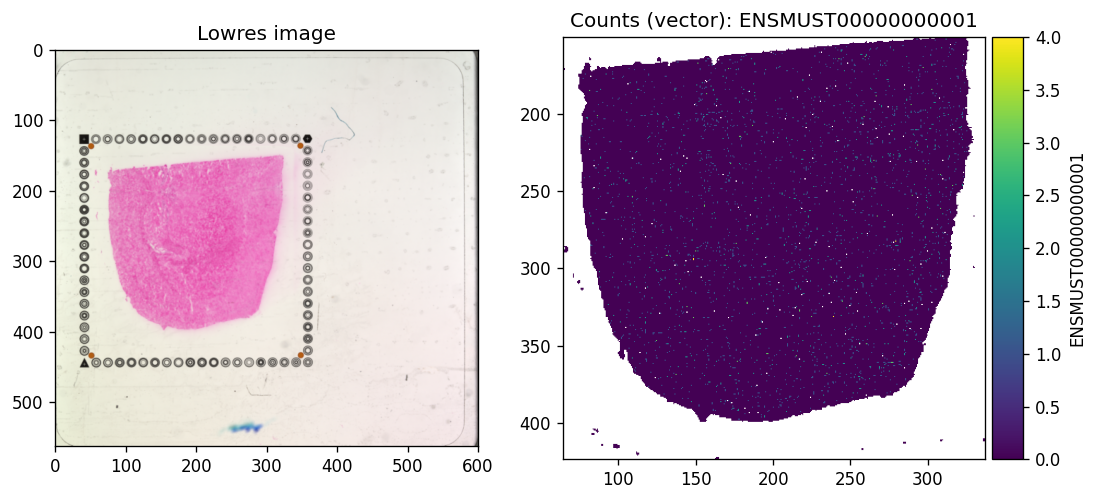

In [11]:
%%time
tx_name = 'ENSMUST00000000001' # Gnai3
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_images(f"{dataset_id}_lowres_image").pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title="Lowres image"
)
sdata.pl.render_shapes(f"{dataset_id}_square_016um", color=tx_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title=f"Counts (vector): {tx_name}"
)

## Spatial variability testing with `SplisosmFFT`

In [12]:
model = SplisosmFFT(neighbor_degree=1, rho=0.99)
model.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key="array_col",
    row_key="array_row",
    layer="counts",
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True
)
model

=== SplisosmFFT
- Number of genes: 1558
- Number of spots: 123658
- Number of spots after rasterization: 175561
- Number of covariates: 0
- Average isoforms per gene: 2.3
=== Model configurations
- Neighborhood degree: 1
- Spatial autocorrelation rho: 0.99
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

While many genes have more than 10 isoforms detected, the effective number of isoforms (adjusted for expression level) is much smaller.

In [13]:
%%time
gene_meta = model.extract_feature_summary(level="gene")
feature_meta = model.extract_feature_summary(level="isoform")
gene_meta.sort_values("perplexity", ascending=False).head(5)

Genes: 100%|██████████| 1558/1558 [00:00<00:00, 1834.66it/s]

CPU times: user 841 ms, sys: 119 ms, total: 960 ms
Wall time: 967 ms


,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
gene,,,,,,
Pantr1,9,7.620990,0.024964,0.032291,0.221045,0.229902
Mtch1,8,7.095370,0.023144,0.029185,0.205137,0.234968
Gas5,17,6.323551,0.111630,0.165667,0.564609,0.476765
Egfl7,6,5.437132,0.014726,0.018689,0.165910,0.272177
Paxx,7,5.433822,0.035930,0.048642,0.276595,0.321363


Next, we run `method="hsic-ir"` to detect spatial variability in isoform usage.

In [14]:
%%time
model.test_spatial_variability(
    method="hsic-ir",
    ratio_transformation="none",
    n_jobs=-1,
    print_progress=True,
)

SV [hsic-ir]: 100%|██████████| 116/116 [00:05<00:00, 22.91it/s]


CPU times: user 24.5 s, sys: 5.52 s, total: 30 s
Wall time: 6.43 s


In [15]:
sv_res_16um = model.get_formatted_test_results(
    "sv", with_gene_summary=True
).sort_values("pvalue_adj")
sv_res_16um.head(5)

,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
1133,Nnat,3.349203e-07,0.0,0.0,2,1.650491,0.073922,0.113628,0.503994,0.799516
1356,Gls,6.044231e-07,0.0,0.0,2,1.460988,0.170721,0.241117,0.614752,0.873793
340,Caly,4.102586e-07,0.0,0.0,4,2.824695,0.052330,0.071544,0.337891,0.579632
610,Fxyd1,2.116209e-07,0.0,0.0,5,3.250710,0.031886,0.043297,0.265310,0.555099
1218,Olfm1,7.099970e-07,0.0,0.0,3,2.023517,0.177611,0.269962,0.701330,0.766378


Let's take a look at the top significant genes and their spatial isoform usage patterns.

In [16]:
sig_001 = int((sv_res_16um["pvalue_adj"] < 0.01).sum())
print(
    "Spatially variable genes (FDR < 0.01, 16um): "
    f"{sig_001} out of {sv_res_16um.shape[0]} total genes"
)
top_genes = sv_res_16um.head(10)["gene"].astype(str).tolist()
top_genes[:5]

Spatially variable genes (FDR < 0.01, 16um): 710 out of 1558 total genes


['Nnat', 'Gls', 'Caly', 'Fxyd1', 'Olfm1']

In [17]:
def plot_gene_tx_maps(
    sdata,
    bin_table: str,
    bin_element: str,
    gene_id: str,
    tx_meta: pd.DataFrame | None = None,
    group_col: str = "gene_ids",
    max_peaks: int = 4,
    hide_zero_count: bool = True,
    hide_zero_ratio: bool = True,
):
    adata = sdata.tables[bin_table]
    if tx_meta is None:
        tx_meta = adata.var.copy()

    if group_col not in tx_meta.columns:
        raise ValueError(f"'{group_col}' not found in tx_meta columns")

    tx_names = tx_meta.index[
        tx_meta[group_col].astype(str) == str(gene_id)
    ].tolist()
    if len(tx_names) == 0:
        raise ValueError(f"No transcripts found for gene id '{gene_id}'")
    if any(tx not in adata.var_names for tx in tx_names):
        raise ValueError(f"Some transcripts not found in {bin_table}.var_names")
    n_peaks = len(tx_names)
    n_shown = min(n_peaks, max_peaks)
    tx_names = tx_names[:n_shown]

    raster_key = ensure_rasterized(sdata, bin_table=bin_table, bin_element=bin_element)
    data = sdata[raster_key].sel(c=tx_names).values
    counts_cube = np.moveaxis(np.asarray(data, dtype=float), 0, -1)

    counts_flat = counts_cube.reshape(-1, counts_cube.shape[-1])
    ratios_flat = counts_to_ratios(counts_flat, transformation="none", nan_filling="none")
    ratios_cube = ratios_flat.numpy().reshape(counts_cube.shape)

    n_tx = counts_cube.shape[-1]
    fig, axes = plt.subplots(2, n_tx, figsize=(4 * n_tx, 7), squeeze=False)

    for i, tx in enumerate(tx_names):
        c = counts_cube[:, :, i]
        r = ratios_cube[:, :, i]
        if hide_zero_count:
            c = np.where(c == 0, np.nan, c)
        if hide_zero_ratio:
            r = np.where(r == 0, np.nan, r)

        im0 = axes[0, i].imshow(np.log1p(c), cmap="Purples", vmin=0.0)
        axes[0, i].set_title(f"Count (log1p)\n{tx}")
        axes[0, i].axis("off")
        fig.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

        vmax = np.nanpercentile(ratios_cube, 99) if np.isfinite(ratios_cube).any() else 1.0
        im1 = axes[1, i].imshow(r, cmap="Reds", vmin=0.0, vmax=vmax)
        axes[1, i].set_title(f"Ratio\n{tx}")
        axes[1, i].axis("off")
        fig.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

    fig.suptitle(f"Gene {gene_id} | showing {n_shown}/{n_peaks} transcripts | {bin_table}", y=1)
    fig.tight_layout()
    plt.show()

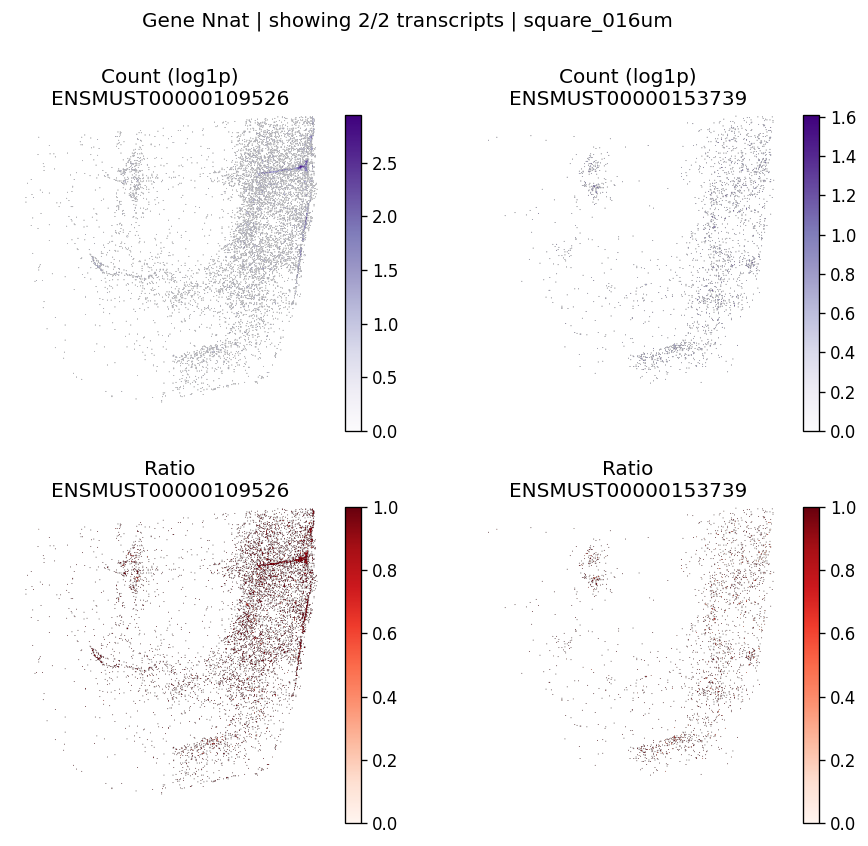

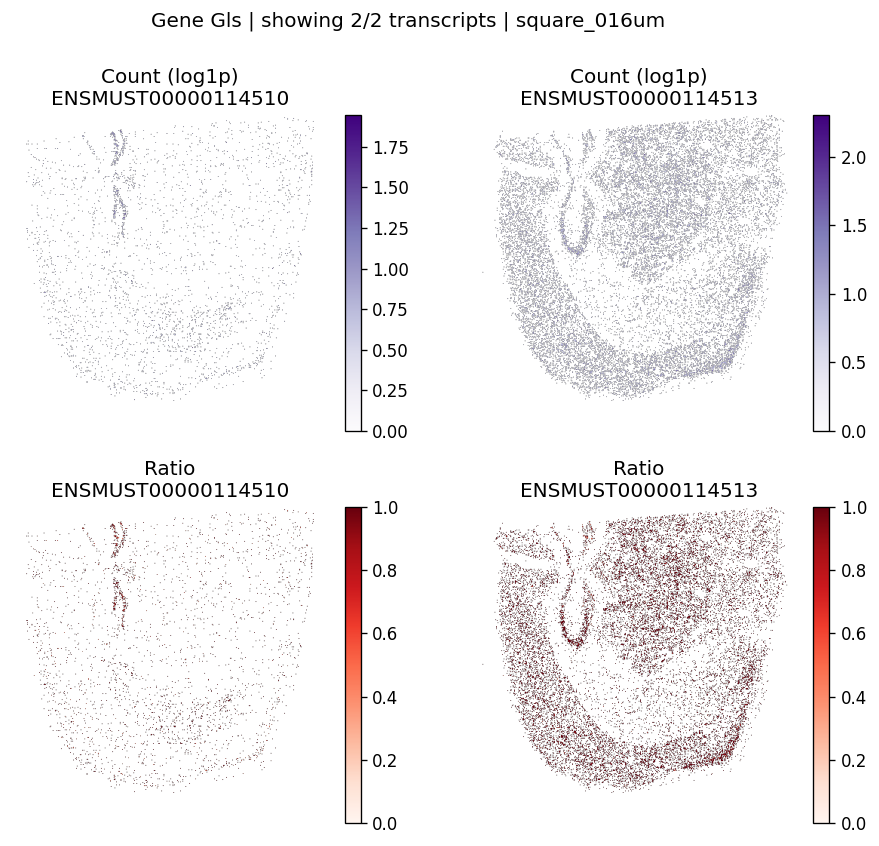

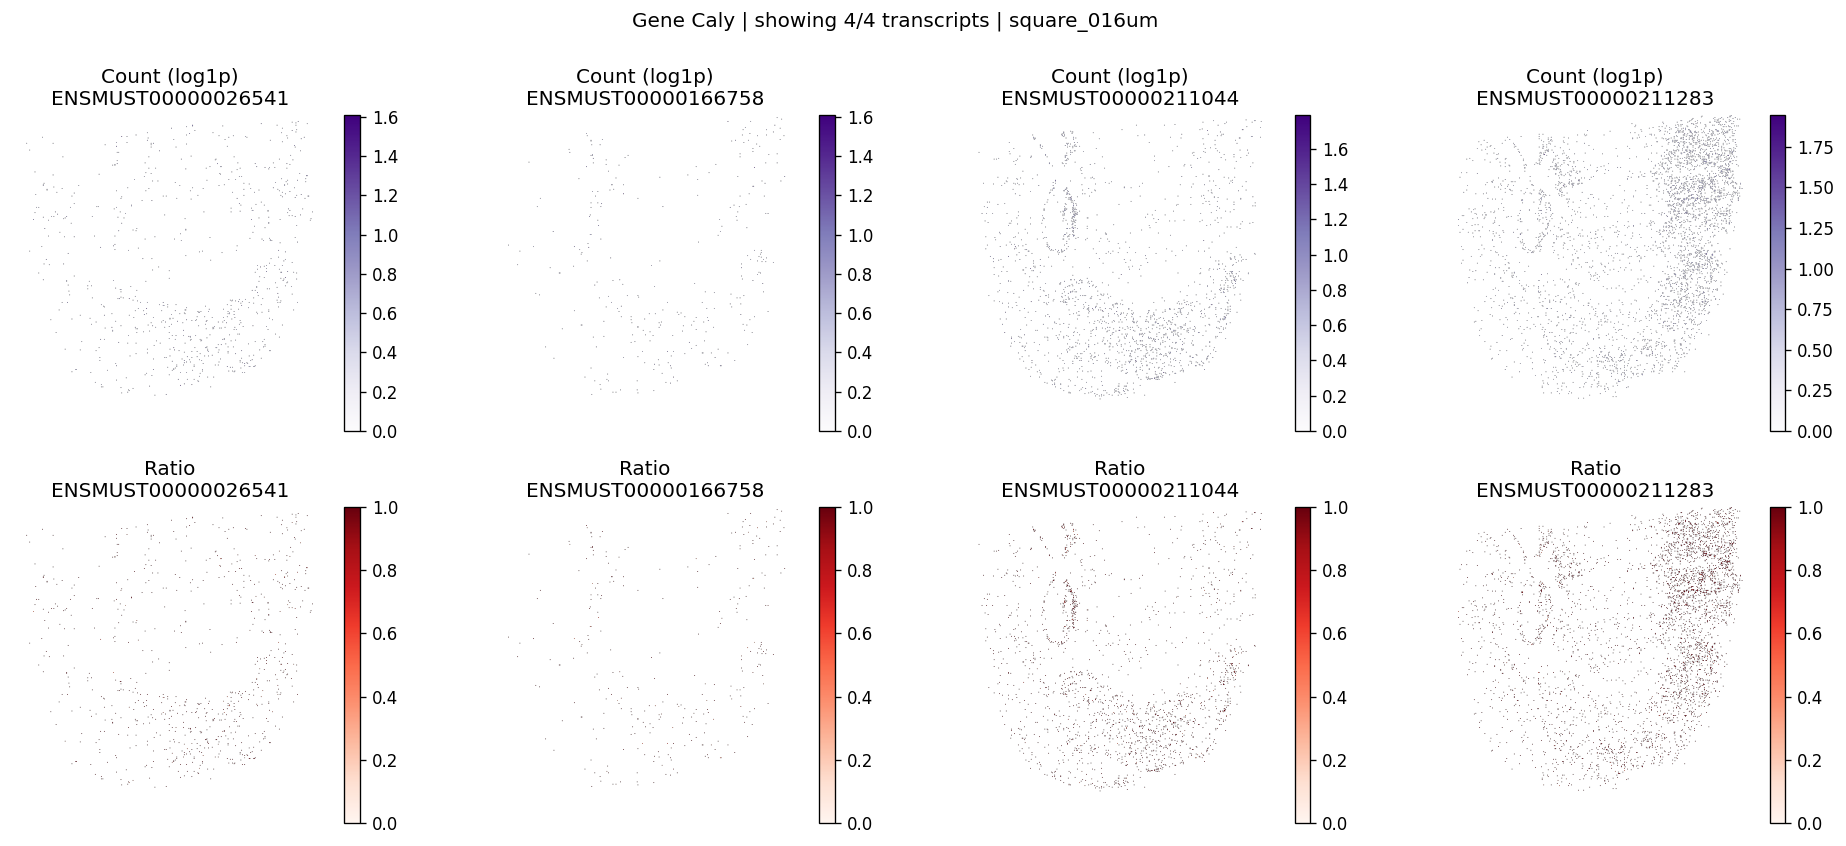

In [18]:
# Visualize maps for a few significant genes
for gene_id in top_genes[:3]:
    plot_gene_tx_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        tx_meta=feature_meta,
        group_col='gene_name',
        max_peaks=6,
        hide_zero_ratio=True,
    )

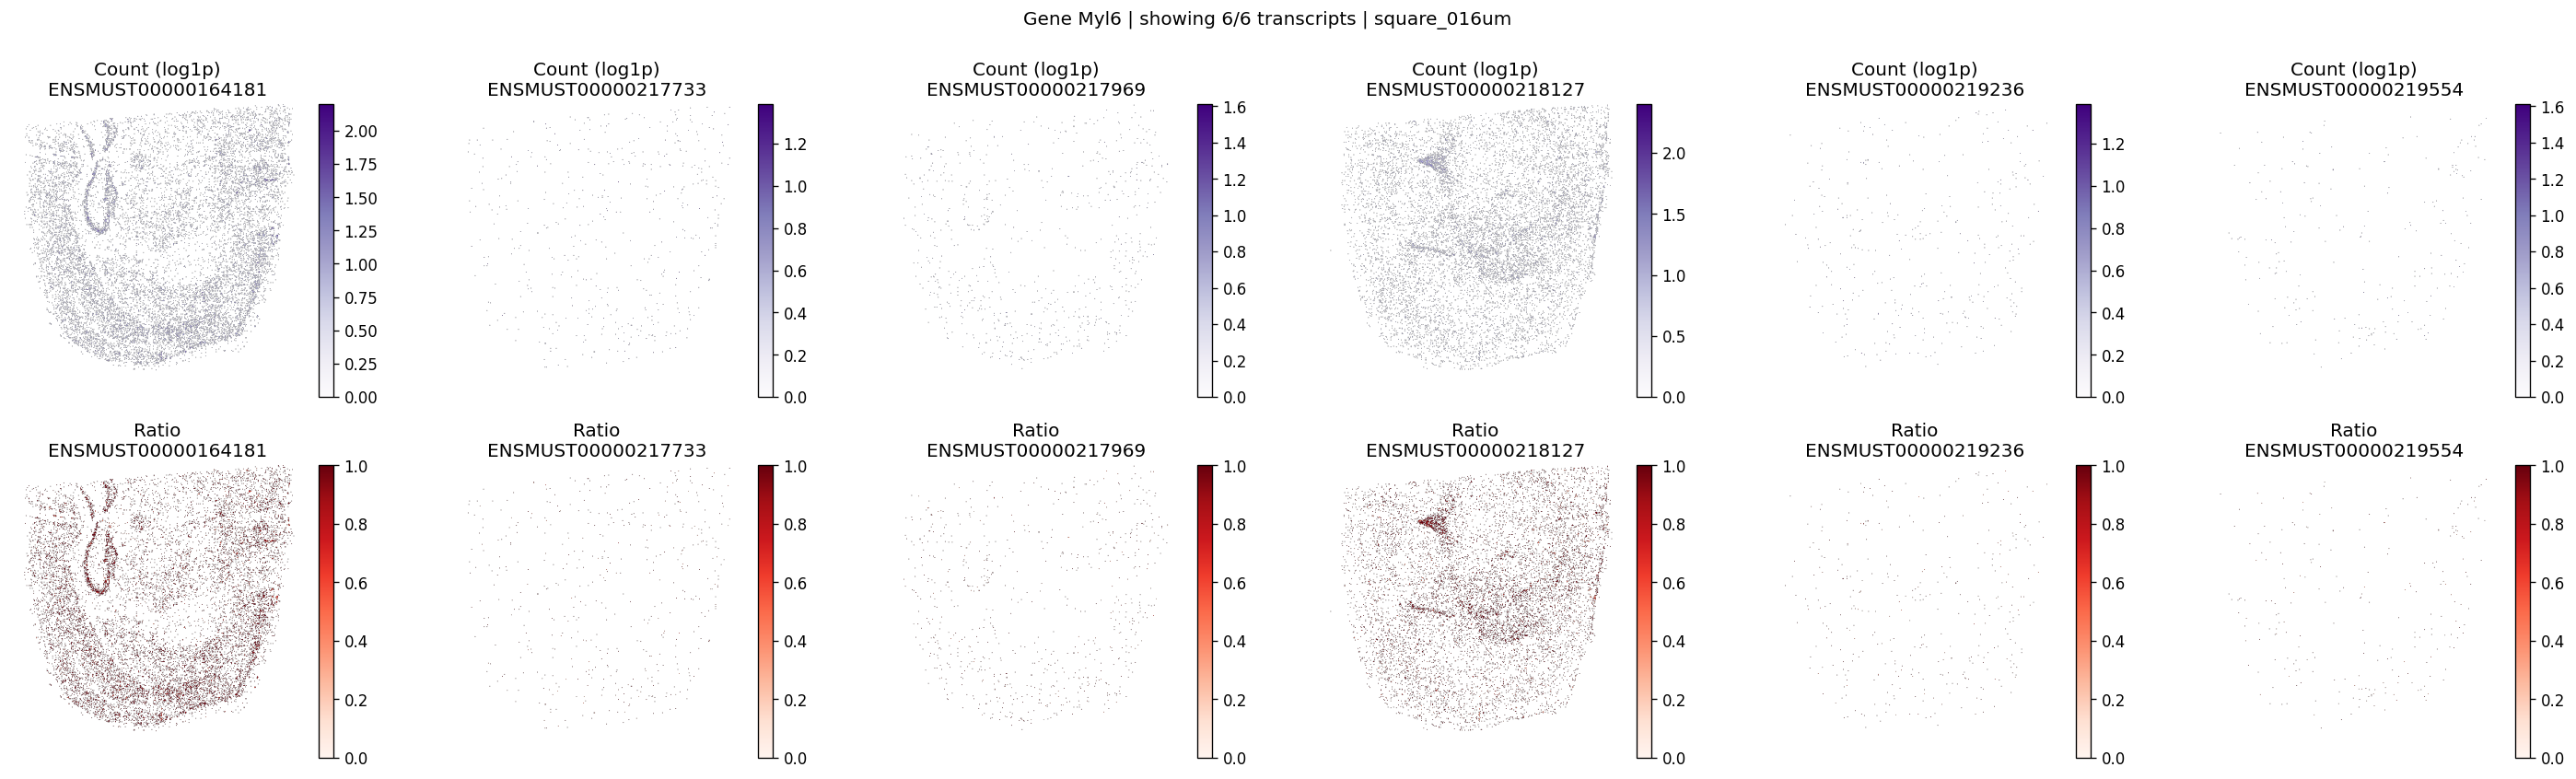

CPU times: user 410 ms, sys: 49.6 ms, total: 460 ms
Wall time: 458 ms


In [19]:
%%time
# Plot an example gene of interest
plot_gene_tx_maps(
    sdata=sdata,
    bin_table=test_table,
    bin_element=test_bins_element,
    gene_id='Myl6',
    tx_meta=feature_meta,
    group_col='gene_name',
    max_peaks=6,
    hide_zero_ratio=True,
)

And the transcript structure of a gene (showing kept isoforms after filtering):

In [20]:
def _open_text(path: Path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt")
    return open(path, "rt")


def _extract_attr(attr_text: str, key: str) -> str | None:
    m = re.search(rf"{re.escape(key)}[= ]\"?([^\";]+)", str(attr_text))
    return m.group(1) if m else None


def _normalize_tx_id(value: str) -> str:
    token = str(value).strip().split("|")[0].split(";")[0].split(" ")[0]
    # Strip Ensembl transcript version only (e.g. ENSMUST....1.2 -> ENSMUST....1)
    m = re.match(r"^(ENSMUST\d+)\.\d+$", token)
    if m:
        return m.group(1)
    return token


def _build_reference_tx_structures(gff_path: Path) -> dict[str, list[dict]]:
    """Build exon structures keyed by reference transcript ID (cmp_ref/ENSMUST)."""
    assembled_meta: dict[str, dict] = {}
    assembled_exons: dict[str, list[tuple[int, int]]] = {}

    with _open_text(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue

            feature_type = parts[2].lower()
            attr = parts[8]

            if feature_type in {"transcript", "mrna"}:
                tx_id = _extract_attr(attr, "transcript_id") or _extract_attr(attr, "ID")
                if not tx_id:
                    continue

                cmp_ref = _extract_attr(attr, "cmp_ref")
                ref_tx_id = _normalize_tx_id(cmp_ref) if cmp_ref else _normalize_tx_id(tx_id)

                assembled_meta[tx_id] = {
                    "assembled_tx_id": tx_id,
                    "ref_tx_id": ref_tx_id,
                    "chrom": parts[0],
                    "strand": parts[6],
                    "class_code": _extract_attr(attr, "class_code") or "",
                    "gene_id": _extract_attr(attr, "ref_gene_id")
                    or _extract_attr(attr, "gene_id")
                    or "",
                    "gene_name": _extract_attr(attr, "ref_gene_name")
                    or _extract_attr(attr, "gene_name")
                    or _extract_attr(attr, "cmp_ref_gene")
                    or "",
                }

            elif feature_type == "exon":
                tx_id = (
                    _extract_attr(attr, "transcript_id")
                    or _extract_attr(attr, "Parent")
                    or _extract_attr(attr, "ID")
                )
                if not tx_id:
                    continue
                assembled_exons.setdefault(tx_id, []).append((int(parts[3]), int(parts[4])))

    ref_to_structs: dict[str, list[dict]] = {}
    for tx_id, meta in assembled_meta.items():
        exons = sorted(assembled_exons.get(tx_id, []))
        if len(exons) == 0:
            continue

        structure = {
            **meta,
            "exons": exons,
            "start": min(e[0] for e in exons),
            "end": max(e[1] for e in exons),
            "n_exons": len(exons),
            "tx_len": sum((e2 - e1) for e1, e2 in exons),
        }
        ref_to_structs.setdefault(meta["ref_tx_id"], []).append(structure)

    return ref_to_structs


def _pick_best_structure(candidates: list[dict]) -> dict:
    """Pick one representative structure per reference transcript."""
    class_rank = {
        "=": 6,
        "k": 5,
        "j": 4,
        "c": 3,
        "i": 2,
        "o": 1,
        "u": 0,
    }

    def _score(c: dict) -> tuple[int, int, int]:
        return (
            class_rank.get(str(c.get("class_code", "")).strip(), -1),
            int(c.get("n_exons", 0)),
            int(c.get("tx_len", 0)),
        )

    return sorted(candidates, key=_score, reverse=True)[0]


def plot_feature_transcript_structure(
    sdata,
    bin_table: str,
    gene_id: str,
    feature_meta: pd.DataFrame,
    group_col: str,
    gff_path: str | Path,
    top_k: int = 8,
    figsize: tuple[float, float] = (8, 4),
):
    """Plot exon structures for reference transcripts selected from feature_meta."""
    adata = sdata.tables[bin_table]
    gff_path = Path(gff_path)

    # 1) Get transcripts for this gene from feature_meta
    gene_mask = feature_meta[group_col].astype(str) == str(gene_id)

    gene_features = feature_meta.loc[gene_mask].copy()
    if gene_features.empty:
        raise ValueError(f"No features found for gene '{gene_id}'")

    feature_names = gene_features.index.tolist()
    x_sub = adata[:, feature_names].layers.get("counts", adata[:, feature_names].X)
    feature_sums = np.asarray(x_sub.sum(axis=0)).ravel()
    order = np.argsort(-feature_sums)

    ref_tx_ids = []
    seen = set()
    for i in order:
        tx = _normalize_tx_id(feature_names[i])
        if tx not in seen:
            ref_tx_ids.append(tx)
            seen.add(tx)
        if len(ref_tx_ids) >= top_k:
            break

    # 2) Query GFF structures by reference transcript ID (via cmp_ref)
    ref_to_structs = _build_reference_tx_structures(gff_path)

    resolved: list[tuple[str, dict]] = []
    missing: list[str] = []
    for ref_tx in ref_tx_ids:
        candidates = ref_to_structs.get(ref_tx, [])
        if len(candidates) == 0:
            missing.append(ref_tx)
            continue
        resolved.append((ref_tx, _pick_best_structure(candidates)))

    if len(resolved) == 0:
        examples = ", ".join(ref_tx_ids[:5])
        raise ValueError(
            "Could not find transcript exon structures in GFF for selected reference transcripts. "
            f"Example IDs: {examples}."
        )

    # 3) Plot exon structures, labeled by reference transcript ID
    fig, ax = plt.subplots(figsize=figsize)
    strand_colors = {"+": "steelblue", "-": "darkorange"}

    y_positions = np.arange(len(resolved))
    x_mins: list[int] = []
    x_maxs: list[int] = []

    for y, (ref_tx, info) in zip(y_positions, resolved, strict=False):
        tx_min, tx_max = int(info["start"]), int(info["end"])
        x_mins.append(tx_min)
        x_maxs.append(tx_max)

        tx_color = strand_colors.get(str(info.get("strand", ".")), "gray")
        ax.plot([tx_min, tx_max], [y, y], color="black", linewidth=0.5, alpha=0.5)

        for exon_start, exon_end in info["exons"]:
            ax.barh(
                y,
                exon_end - exon_start,
                left=exon_start,
                height=0.6,
                color=tx_color,
                edgecolor="black",
            )

    ax.set_yticks(y_positions)
    ax.set_yticklabels([ref_tx for ref_tx, _ in resolved], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Genomic coordinate (bp)")
    ax.set_title(f"Transcript structure of detected reference isoforms: {gene_id}")
    ax.grid(True, axis="x", alpha=0.3)

    if x_mins and x_maxs:
        x_pad = (max(x_maxs) - min(x_mins)) * 0.02
        if x_pad > 0:
            ax.set_xlim(min(x_mins) - x_pad, max(x_maxs) + x_pad)

    direction_note = "Transcript 5'->3' direction: + strand left->right (blue) | - strand right->left (orange)"
    fig.text(0.5, 0.01, direction_note, ha="center", va="bottom", fontsize=10, color="black")

    if missing:
        note = f"Missing in GFF: {', '.join(missing[:4])}" + (" ..." if len(missing) > 4 else "")
        fig.text(0.5, 0.035, note, ha="center", va="bottom", fontsize=8, color="dimgray")

    fig.tight_layout(rect=(0.0, 0.07, 1.0, 1.0))
    plt.show()

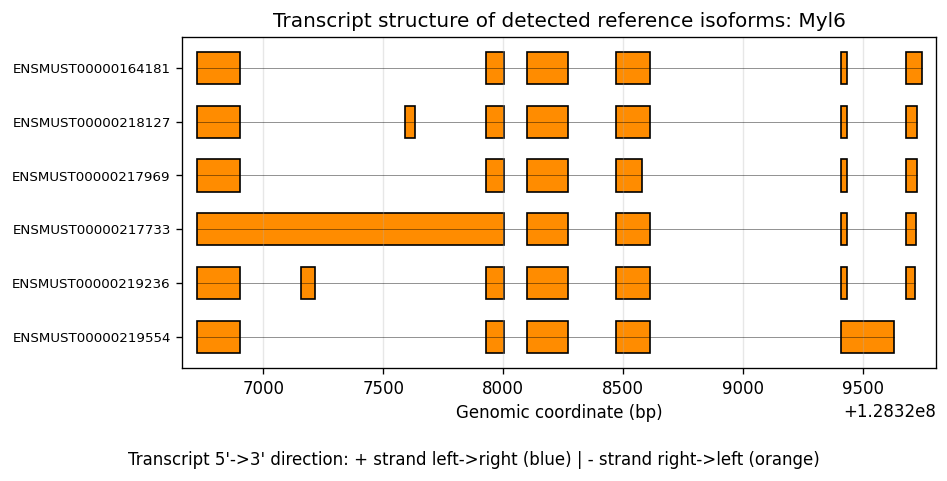

CPU times: user 2.93 s, sys: 59.3 ms, total: 2.99 s
Wall time: 3.01 s


In [21]:
%%time
# Plot an example gene of interest with transcript structures
plot_feature_transcript_structure(
    sdata=sdata,
    bin_table=test_table,
    gene_id="Myl6",
    feature_meta=feature_meta,
    group_col="gene_name",
    gff_path=gff_file,
    top_k=10,
)

## Method comparison: `SplisosmFFT` vs `SplisosmNP`

We now compare FFT-accelerated and non-parametric spatial variability tests at 16 µm resolution.

**Note:** Since v1.2, `SplisosmNP` SV tests use Liu's approximation from full-rank spatial-kernel cumulants by default.

For large implicit CAR kernels, `null_configs={"n_probes": m}` controls the Hutchinson trace budget. Smaller `m` is faster but noisier. To emphasize broad smooth patterns, prefer increasing `rho` (for example, `rho=0.999`) rather than rank truncation.

In [22]:
%%time
# Run SplisosmNP at 16µm for direct comparison with SplisosmFFT
model_np = SplisosmNP(
    k_neighbors=4,
    rho=0.99,
    standardize_cov=False # faster
)
model_np.setup_data(
    adata=sdata.tables[test_table],
    spatial_key='spatial', # adata.obsm key for spatial coordinates
    layer='counts',
    group_iso_by=group_iso_by, # 'gene_ids'
    gene_names=gene_name_col, # 'gene_ids'
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    min_component_size=10 # remove disconnected tissue fragments if any
)

/Users/jysumac/Projects/SPLISOSM/src/splisosm/utils/preprocessing.py:832: UserWarning: Removed 100 spot(s) belonging to graph components with fewer than 10 member(s). 123558 spot(s) remain.
  spatial_inputs = _filter_small_components(


CPU times: user 505 ms, sys: 112 ms, total: 616 ms
Wall time: 618 ms


In [23]:
%%time
model_np.test_spatial_variability(
    method='hsic-ir',
    null_configs={"n_probes": 60},
    ratio_transformation='none',
    print_progress=True,
)

SV [hsic-ir]: 100%|██████████| 116/116 [00:04<00:00, 27.38it/s]


CPU times: user 30.8 s, sys: 3.42 s, total: 34.3 s
Wall time: 6.24 s


Compare p-values between `SplisosmFFT` and `SplisosmNP`:

In [24]:
# Extract results and merge
sv_np = model_np.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
sv_np = sv_np.rename(columns={'pvalue': 'pvalue_np'})

comparison = sv_res_16um[['gene', 'pvalue']].copy()
comparison = comparison.rename(columns={'pvalue': 'pvalue_fft'})
comparison = comparison.merge(sv_np, on='gene', how='inner')

corr, _ = spearmanr(comparison['pvalue_fft'], comparison['pvalue_np'])

print(f'Genes tested in both methods: {len(comparison)}')
print(f'== Significant in SplisosmFFT (FDR < 0.01): {(comparison["pvalue_fft"] < 0.01).sum()}')
print(f'== Significant in SplisosmNP (FDR < 0.01): {(comparison["pvalue_np"] < 0.01).sum()}')
print(f'== P-value correlation (Spearman rho): {corr:.4f}')

Genes tested in both methods: 1558
== Significant in SplisosmFFT (FDR < 0.01): 790
== Significant in SplisosmNP (FDR < 0.01): 538
== P-value correlation (Spearman rho): 0.9903


The two approaches yield almost identical rankings. `SplisosmFFT` shows slightly smaller p-values for top genes due to zero-padding that increases sample size (`n=123,658` before vs `n=175,561` after rasterization).

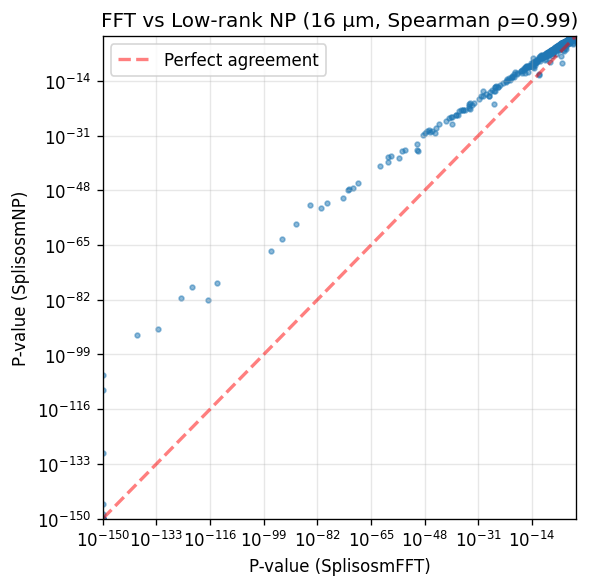

In [25]:
# Scatter plot comparison
fig, ax = plt.subplots(figsize=(5, 5))
x = comparison['pvalue_fft'].to_numpy()
y = comparison['pvalue_np'].to_numpy()

ax.scatter(x + 1e-150, y + 1e-150, s=8, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('P-value (SplisosmFFT)')
ax.set_ylabel('P-value (SplisosmNP)')
ax.set_title(f'FFT vs Low-rank NP (16 µm, Spearman ρ={corr:.2f})')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
lims = [1e-150, 1.0]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect agreement', linewidth=2)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

## For reproducibility

In [26]:
import sys
from datetime import date
import splisosm

print("Last updated:", date.today())
print("Python:", sys.version.split()[0])
print("splisosm:", getattr(splisosm, "__version__", "unknown"))

Last updated: 2026-04-27
Python: 3.12.13
splisosm: 1.2.0rc2.dev4+g83955c42e.d20260427
